In [ ]:
!pip install -U torch torchvision torchaudio seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.7/915.7 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch, torchvision as tv
from torch.utils.data import DataLoader
from torchvision import transforms, datasets

import numpy as np
import pandas as pd
import os, time, ast, zipfile, warnings, logging, joblib

from sklearn.model_selection import StratifiedShuffleSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, matthews_corrcoef
)

warnings.filterwarnings("ignore")
logging.getLogger("torchvision").setLevel(logging.ERROR)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/datasets/IQ-OTHNCCD"

RESULTS_DIR = "/content/drive/MyDrive/results"
MODEL_DIR   = "/content/drive/MyDrive/saved_models"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)


In [ ]:
tfms = {
    "SqueezeNet": transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]),
    "EfficientNetB0": transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]),
    "EfficientNetB1": transforms.Compose([
        transforms.Resize((240,240)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]),
    "EfficientNetB2": transforms.Compose([
        transforms.Resize((260,260)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
}


In [ ]:
backbones = {
    "SqueezeNet": (
        tv.models.squeezenet1_1,
        tv.models.SqueezeNet1_1_Weights.DEFAULT
    ),
    "EfficientNetB0": (
        tv.models.efficientnet_b0,
        tv.models.EfficientNet_B0_Weights.IMAGENET1K_V1
    ),
    "EfficientNetB1": (
        tv.models.efficientnet_b1,
        tv.models.EfficientNet_B1_Weights.IMAGENET1K_V1
    ),
    "EfficientNetB2": (
        tv.models.efficientnet_b2,
        tv.models.EfficientNet_B2_Weights.IMAGENET1K_V1
    )
}


In [ ]:
def extract(loader, feature_extractor):
    feats, labels = [], []
    with torch.no_grad():
        for imgs, lab in loader:
            imgs = imgs.to(device)
            out = feature_extractor(imgs)
            feats.append(out.cpu().numpy())
            labels.append(lab.numpy())
    return np.vstack(feats), np.concatenate(labels)


In [ ]:
def eval_model(clf, X_te, y_te):
    y_pr = clf.predict(X_te)

    acc = accuracy_score(y_te, y_pr)
    f1  = f1_score(y_te, y_pr, average="macro")
    prec = precision_score(y_te, y_pr, average="macro", zero_division=0)
    rec  = recall_score(y_te, y_pr, average="macro")
    mcc  = matthews_corrcoef(y_te, y_pr)

    y_bin = label_binarize(y_te, classes=np.unique(y_te))
    auc = roc_auc_score(y_bin, clf.predict_proba(X_te),
                        average="macro", multi_class="ovr")

    return acc, f1, prec, rec, mcc, auc


In [ ]:
splits = [0.34, 0.30, 0.20, 0.10]
all_results = []

for bb_name, (bb_func, bb_weights) in backbones.items():
    print(f"\nRunning Backbone: {bb_name}")

    ds = datasets.ImageFolder(DATASET_PATH, transform=tfms[bb_name])
    y = np.array([s[1] for s in ds.samples])

    net = bb_func(weights=bb_weights).to(device).eval()

    if bb_name == "SqueezeNet":
        feature_extractor = torch.nn.Sequential(
            net.features,
            torch.nn.AdaptiveAvgPool2d((1,1)),
            torch.nn.Flatten()
        )
    else:
        feature_extractor = torch.nn.Sequential(
            net.features,
            net.avgpool,
            torch.nn.Flatten()
        )

    for ts in splits:
        split_str = f"{round((1-ts)*100)}:{round(ts*100)}"
        print(" Split:", split_str)

        sss = StratifiedShuffleSplit(n_splits=1, test_size=ts, random_state=42)
        tr_idx, te_idx = next(sss.split(np.zeros(len(y)), y))

        tr_loader = DataLoader(
            torch.utils.data.Subset(ds, tr_idx),
            batch_size=16, shuffle=False, num_workers=0
        )
        te_loader = DataLoader(
            torch.utils.data.Subset(ds, te_idx),
            batch_size=16, shuffle=False, num_workers=0
        )

        X_tr, y_tr = extract(tr_loader, feature_extractor)
        X_te, y_te = extract(te_loader, feature_extractor)

        models = {
            "lr": (
                Pipeline([
                    ("sc", StandardScaler()),
                    ("lr", LogisticRegression(max_iter=2000, multi_class="multinomial"))
                ]),
                {"lr__C":[0.01,0.1,1,10]}
            ),
            "svm": (
                Pipeline([
                    ("sc", StandardScaler()),
                    ("svm", SVC(kernel="rbf", probability=True))
                ]),
                {"svm__C":[0.1,1,10], "svm__gamma":["scale",0.01,0.001]}
            ),
            "rf": (
                RandomForestClassifier(random_state=42),
                {"n_estimators":[100,200], "max_depth":[None,10,20]}
            )
        }

        for name, (model, params) in models.items():
            print("  Training:", name.upper())

            gs = GridSearchCV(
                model, params, cv=3,
                scoring="accuracy", n_jobs=-1
            )
            gs.fit(X_tr, y_tr)

            best_model = gs.best_estimator_

            # ---- SAVE MODEL ----
            model_file = f"{bb_name}_{split_str}_{name}.joblib"
            model_path = os.path.join(MODEL_DIR, model_file)
            joblib.dump(best_model, model_path)

            acc, f1, prec, rec, mcc, auc = eval_model(
                best_model, X_te, y_te
            )

            all_results.append({
                "Backbone": bb_name,
                "Split": split_str,
                "Model": name,
                "Accuracy": acc,
                "F1": f1,
                "Precision": prec,
                "Recall": rec,
                "MCC": mcc,
                "AUC": auc,
                "BestParams": str(gs.best_params_),
                "SavedModel": model_path
            })



Running Backbone: SqueezeNet
Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


100%|██████████| 4.73M/4.73M [00:00<00:00, 172MB/s]


 Split: 66:34
  Training: LR
  Training: SVM
  Training: RF
 Split: 70:30
  Training: LR
  Training: SVM
  Training: RF
 Split: 80:20
  Training: LR
  Training: SVM
  Training: RF
 Split: 90:10
  Training: LR
  Training: SVM
  Training: RF

Running Backbone: EfficientNetB0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 232MB/s]


 Split: 66:34
  Training: LR
  Training: SVM
  Training: RF
 Split: 70:30
  Training: LR
  Training: SVM
  Training: RF
 Split: 80:20
  Training: LR
  Training: SVM
  Training: RF
 Split: 90:10
  Training: LR
  Training: SVM
  Training: RF

Running Backbone: EfficientNetB1
Downloading: "https://download.pytorch.org/models/efficientnet_b1_rwightman-bac287d4.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b1_rwightman-bac287d4.pth


100%|██████████| 30.1M/30.1M [00:00<00:00, 200MB/s]


 Split: 66:34
  Training: LR
  Training: SVM
  Training: RF
 Split: 70:30
  Training: LR
  Training: SVM
  Training: RF
 Split: 80:20
  Training: LR
  Training: SVM
  Training: RF
 Split: 90:10
  Training: LR
  Training: SVM
  Training: RF

Running Backbone: EfficientNetB2
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 114MB/s]


 Split: 66:34
  Training: LR
  Training: SVM
  Training: RF
 Split: 70:30
  Training: LR
  Training: SVM
  Training: RF
 Split: 80:20
  Training: LR
  Training: SVM
  Training: RF
 Split: 90:10
  Training: LR
  Training: SVM
  Training: RF


In [ ]:
df = pd.DataFrame(all_results)

# Display full table without truncation
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

display(df)


,Backbone,Split,Model,Accuracy,F1,Precision,Recall,MCC,AUC,BestParams,SavedModel
0,SqueezeNet,66:34,lr,0.954424,0.900848,0.935965,0.879087,0.922226,0.992703,{'lr__C': 0.1},/content/drive/MyDrive/saved_models/SqueezeNet...
1,SqueezeNet,66:34,svm,0.954424,0.917441,0.947215,0.896385,0.921524,0.992720,"{'svm__C': 10, 'svm__gamma': 0.001}",/content/drive/MyDrive/saved_models/SqueezeNet...
2,SqueezeNet,66:34,rf,0.935657,0.856151,0.950968,0.822176,0.891110,0.987992,"{'max_depth': None, 'n_estimators': 100}",/content/drive/MyDrive/saved_models/SqueezeNet...
3,SqueezeNet,70:30,lr,0.963636,0.923769,0.943766,0.908667,0.937602,0.991780,{'lr__C': 10},/content/drive/MyDrive/saved_models/SqueezeNet...
4,SqueezeNet,70:30,svm,0.957576,0.922284,0.947942,0.903333,0.926894,0.994657,"{'svm__C': 10, 'svm__gamma': 0.001}",/content/drive/MyDrive/saved_models/SqueezeNet...
5,SqueezeNet,70:30,rf,0.942424,0.871110,0.955625,0.837259,0.902764,0.990161,"{'max_depth': None, 'n_estimators': 100}",/content/drive/MyDrive/saved_models/SqueezeNet...
6,SqueezeNet,80:20,lr,0.945455,0.896421,0.900516,0.892570,0.906010,0.994226,{'lr__C': 10},/content/drive/MyDrive/saved_models/SqueezeNet...
7,SqueezeNet,80:20,svm,0.972727,0.956042,0.967003,0.946285,0.952993,0.997124,"{'svm__C': 10, 'svm__gamma': 0.001}",/content/drive/MyDrive/saved_models/SqueezeNet...
8,SqueezeNet,80:20,rf,0.954545,0.902451,0.964109,0.870984,0.922989,0.998777,"{'max_depth': None, 'n_estimators': 200}",/content/drive/MyDrive/saved_models/SqueezeNet...
9,SqueezeNet,90:10,lr,0.963636,0.928571,0.928571,0.928571,0.937642,0.994398,{'lr__C': 1},/content/drive/MyDrive/saved_models/SqueezeNet...


In [ ]:
highest_accuracy_row = df.loc[df['Accuracy'].idxmax()]
display(highest_accuracy_row)

,34
Backbone,EfficientNetB1
Split,90:10
Model,svm
Accuracy,0.990909
F1,0.982651
Precision,0.974359
Recall,0.992063
MCC,0.984624
AUC,1.0
BestParams,"{'svm__C': 10, 'svm__gamma': 'scale'}"


In [ ]:
import torch, torchvision as tv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from torch.utils.data import DataLoader
from torchvision import datasets
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/datasets/IQ-OTHNCCD"
MODEL_DIR = "/content/drive/MyDrive/saved_models"
SAVE_PLOT_DIR = "/content/drive/MyDrive/results/efficientnet_b1_plots"

os.makedirs(SAVE_PLOT_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

splits = {
    "66:34": 0.34,
    "70:30": 0.30,
    "80:20": 0.20,
    "90:10": 0.10
}


In [ ]:
tfm = transforms.Compose([
    transforms.Resize((240,240)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

ds = datasets.ImageFolder(DATASET_PATH, transform=tfm)
class_names = ds.classes
n_classes = len(class_names)

print("Classes:", class_names)


Classes: ['Bengin cases', 'Malignant cases', 'Normal cases']


In [ ]:
net = tv.models.efficientnet_b1(
    weights=tv.models.EfficientNet_B1_Weights.IMAGENET1K_V1
).to(device).eval()

feature_extractor = torch.nn.Sequential(
    net.features,
    net.avgpool,
    torch.nn.Flatten()
)


In [ ]:
def extract_features(loader):
    feats, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = feature_extractor(x)
            feats.append(out.cpu().numpy())
            labels.append(y.numpy())
    return np.vstack(feats), np.concatenate(labels)



Confusion Matrix — Split 66:34


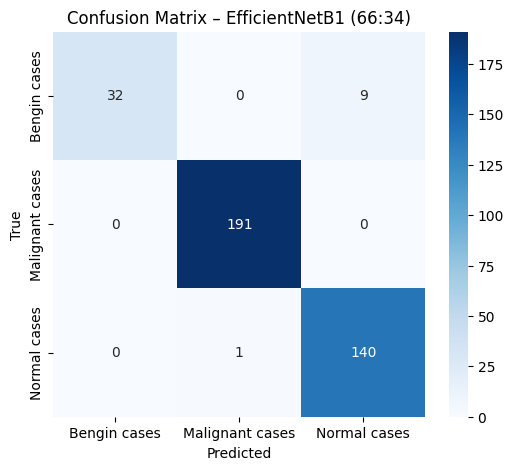


Confusion Matrix — Split 70:30


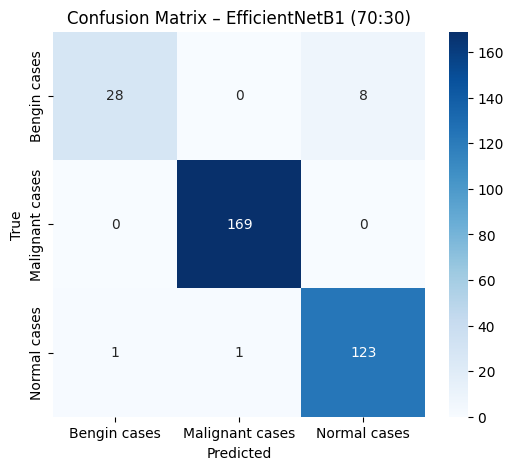


Confusion Matrix — Split 80:20


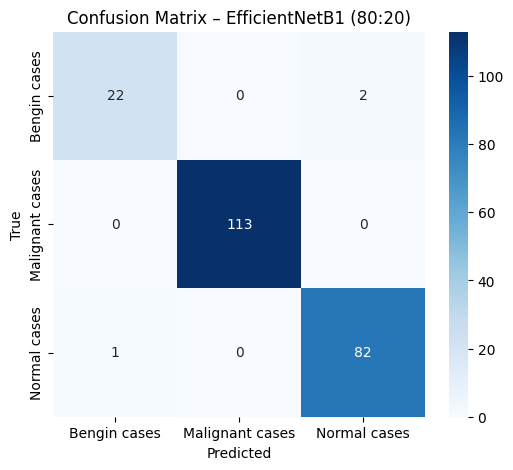


Confusion Matrix — Split 90:10


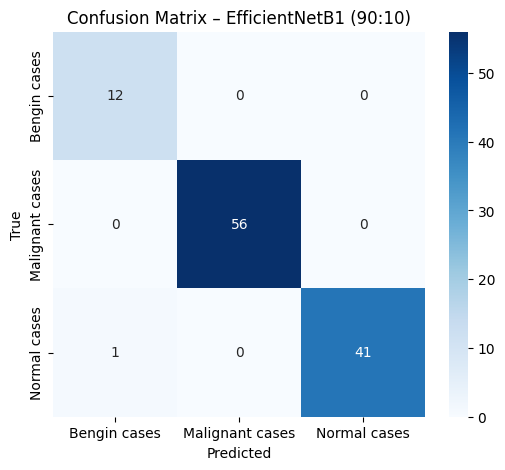

In [ ]:
for split_name, ts in splits.items():
    print(f"\nConfusion Matrix — Split {split_name}")

    y = np.array([s[1] for s in ds.samples])
    sss = StratifiedShuffleSplit(n_splits=1, test_size=ts, random_state=42)
    _, te_idx = next(sss.split(np.zeros(len(y)), y))

    te_loader = DataLoader(
        torch.utils.data.Subset(ds, te_idx),
        batch_size=16, shuffle=False, num_workers=0
    )

    X_te, y_te = extract(te_loader)

    model_path = os.path.join(
        MODEL_DIR, f"EfficientNetB1_{split_name}_svm.joblib"
    )
    clf = joblib.load(model_path)
    y_pred = clf.predict(X_te)

    cm = confusion_matrix(y_te, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm, annot=True, fmt="d",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues"
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix – EfficientNetB1 ({split_name})")

    save_path = os.path.join(
        SAVE_PLOT_DIR, f"CM_EfficientNetB1_{split_name}.png"
    )
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


Classes: ['Bengin cases', 'Malignant cases', 'Normal cases']

Processing split 66:34


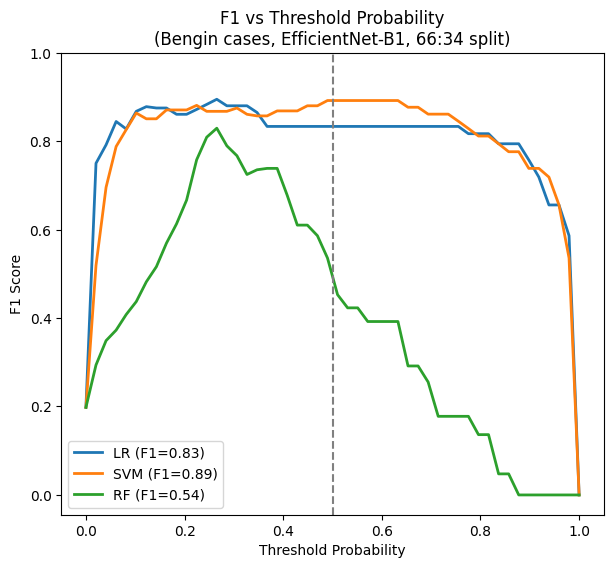

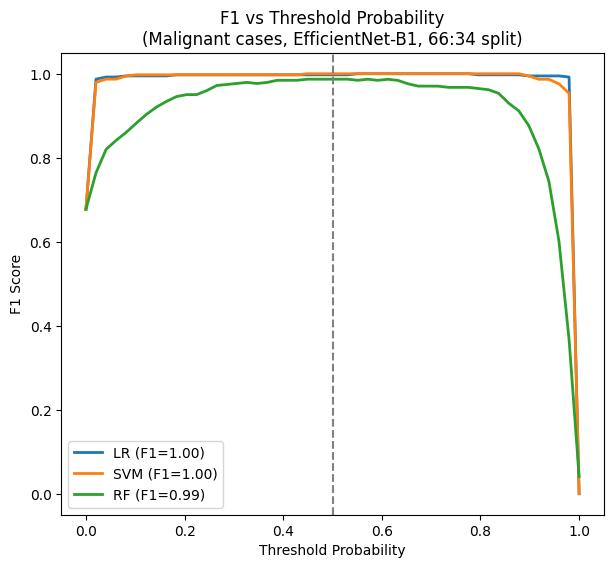

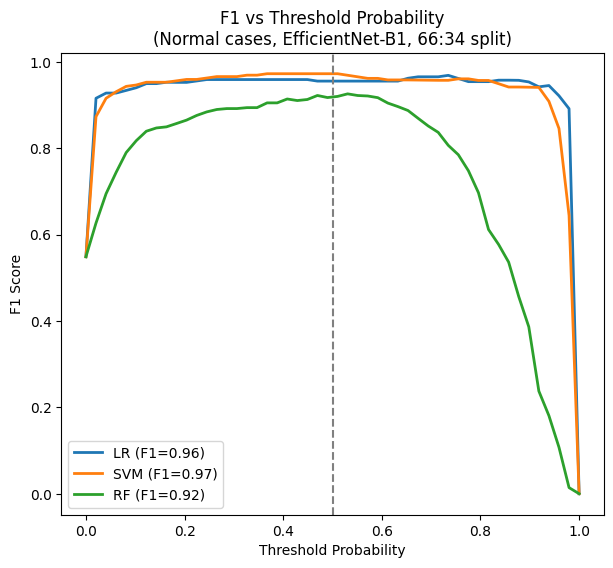


Processing split 70:30


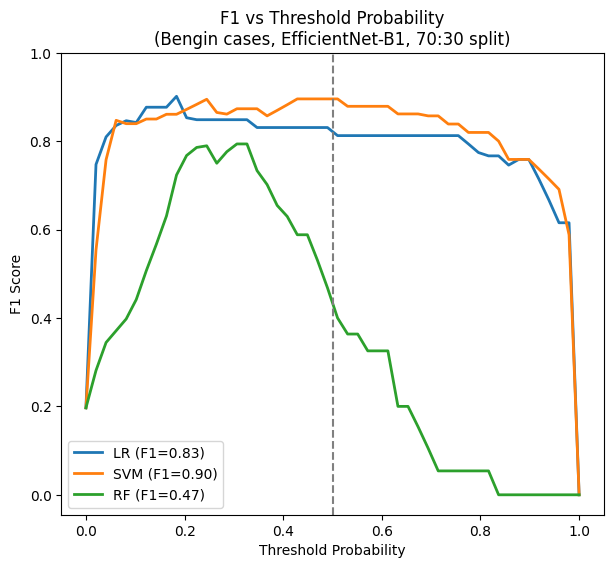

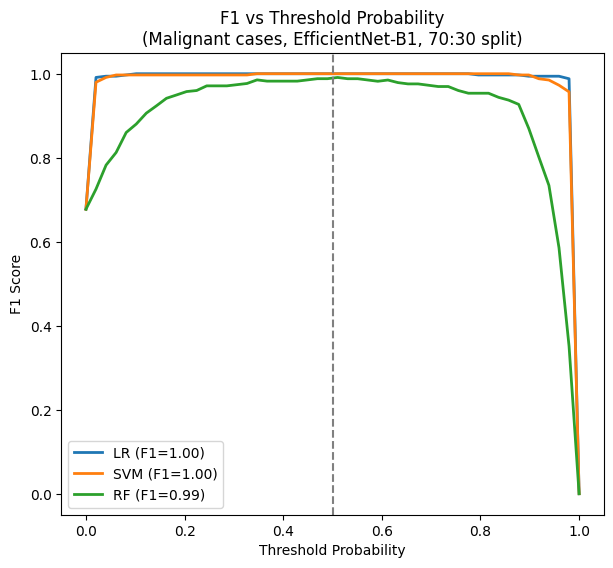

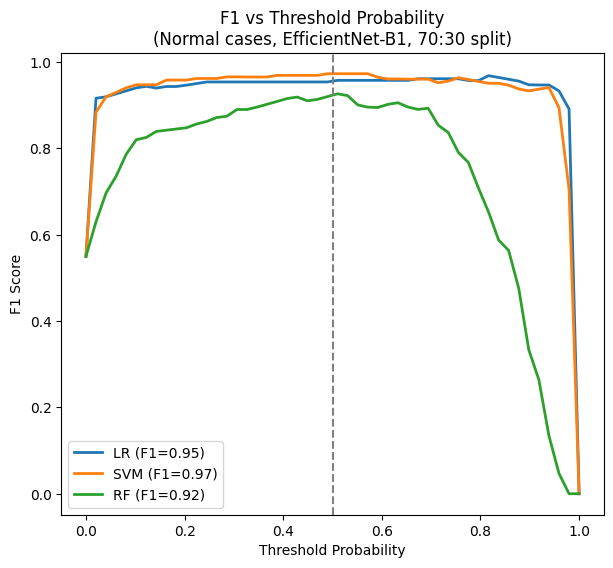


Processing split 80:20


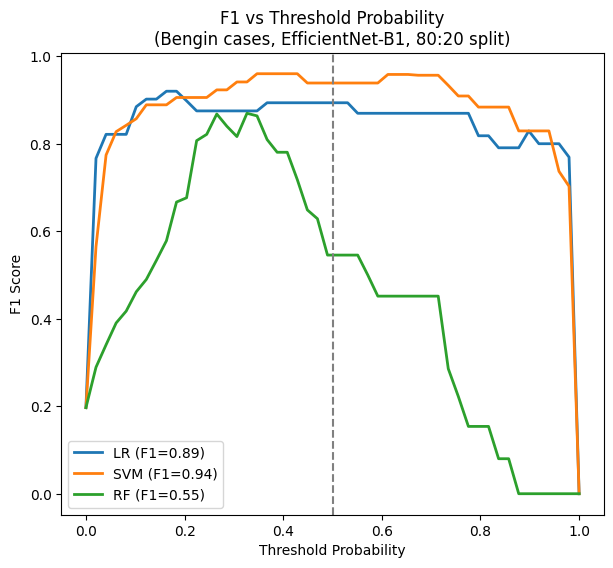

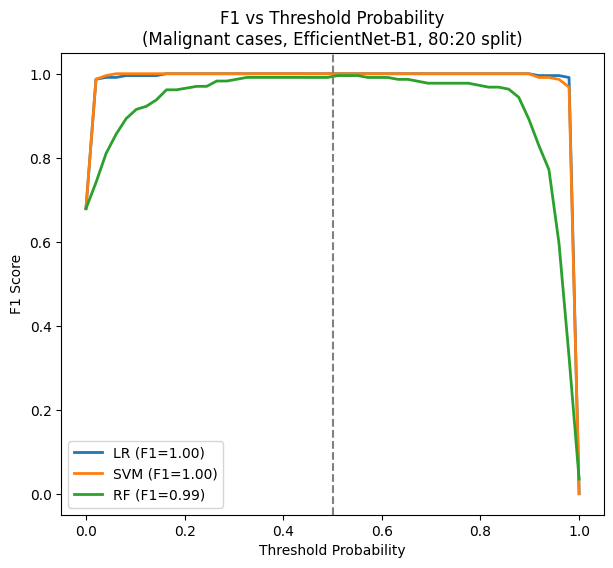

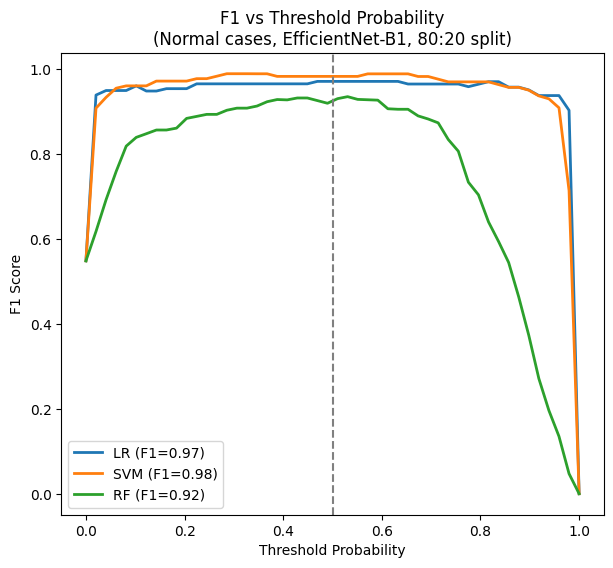


Processing split 90:10


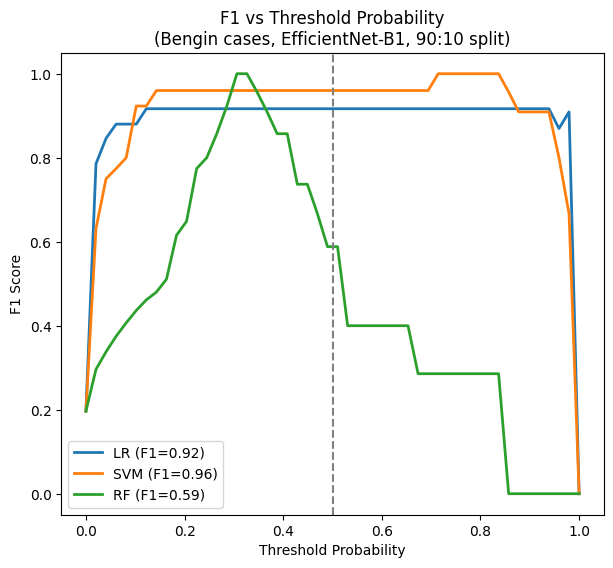

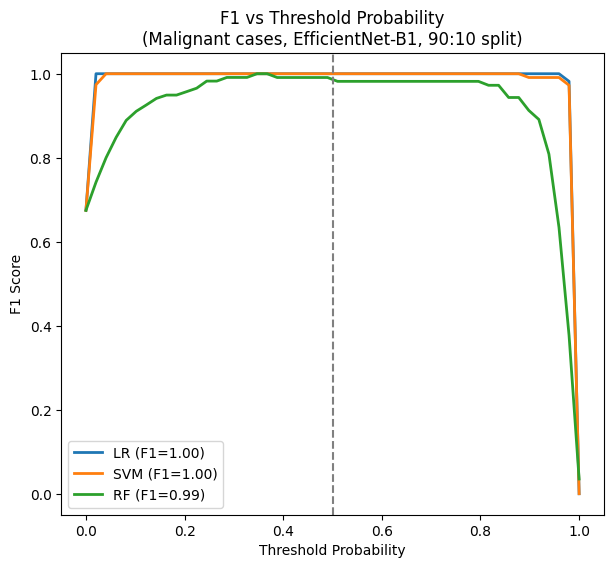

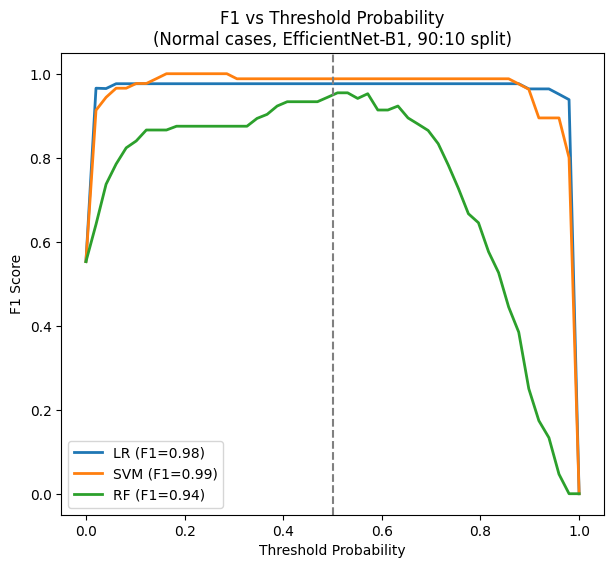

In [ ]:


import torch, torchvision as tv
import numpy as np
import matplotlib.pyplot as plt
import joblib, os

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score

# ---------- PATHS ----------
DATASET_PATH = "/content/drive/MyDrive/datasets/IQ-OTHNCCD"
MODEL_DIR = "/content/drive/MyDrive/saved_models"
SAVE_DIR = "/content/drive/MyDrive/results/F1_vs_Threshold_EfficientNetB1"

os.makedirs(SAVE_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

# ---------- SPLITS ----------
splits = {
    "66:34": 0.34,
    "70:30": 0.30,
    "80:20": 0.20,
    "90:10": 0.10
}

thresholds = np.linspace(0.0, 1.0, 50)

# ---------- DATASET ----------
transform = transforms.Compose([
    transforms.Resize((240,240)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

ds = datasets.ImageFolder(DATASET_PATH, transform=transform)
class_names = ds.classes
n_classes = len(class_names)

print("Classes:", class_names)

# ---------- EfficientNet-B1 Feature Extractor ----------
net = tv.models.efficientnet_b1(
    weights=tv.models.EfficientNet_B1_Weights.IMAGENET1K_V1
).to(device).eval()

feature_extractor = torch.nn.Sequential(
    net.features,
    net.avgpool,
    torch.nn.Flatten()
)

# ---------- Feature Extraction ----------
def extract_features(loader):
    feats, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = feature_extractor(x)
            feats.append(out.cpu().numpy())
            labels.append(y.numpy())
    return np.vstack(feats), np.concatenate(labels)

# ---------- MAIN LOOP ----------
for split_name, test_size in splits.items():
    print(f"\nProcessing split {split_name}")

    y_all = np.array([s[1] for s in ds.samples])
    sss = StratifiedShuffleSplit(
        n_splits=1, test_size=test_size, random_state=42
    )
    _, te_idx = next(sss.split(np.zeros(len(y_all)), y_all))

    te_loader = DataLoader(
        torch.utils.data.Subset(ds, te_idx),
        batch_size=16, shuffle=False, num_workers=0
    )

    X_te, y_te = extract_features(te_loader)

    # Load models
    models = {
        "LR": joblib.load(os.path.join(MODEL_DIR,
               f"EfficientNetB1_{split_name}_lr.joblib")),
        "SVM": joblib.load(os.path.join(MODEL_DIR,
               f"EfficientNetB1_{split_name}_svm.joblib")),
        "RF": joblib.load(os.path.join(MODEL_DIR,
               f"EfficientNetB1_{split_name}_rf.joblib"))
    }

    probs = {m: clf.predict_proba(X_te) for m, clf in models.items()}

    # ---------- Plot for each class ----------
    for class_idx, class_name in enumerate(class_names):

        plt.figure(figsize=(7,6))

        for model_name, y_prob in probs.items():
            y_true = (y_te == class_idx).astype(int)
            f1_scores = []

            for th in thresholds:
                y_pred = (y_prob[:, class_idx] >= th).astype(int)
                f1 = f1_score(y_true, y_pred, zero_division=0)
                f1_scores.append(f1)

            # F1 at threshold 0.5
            idx_05 = np.argmin(np.abs(thresholds - 0.5))
            f1_05 = f1_scores[idx_05]

            plt.plot(
                thresholds, f1_scores, linewidth=2,
                label=f"{model_name} (F1={f1_05:.2f})"
            )

        plt.axvline(0.5, linestyle="--", color="gray")
        plt.xlabel("Threshold Probability")
        plt.ylabel("F1 Score")
        plt.title(
            f"F1 vs Threshold Probability\n"
            f"({class_name}, EfficientNet-B1, {split_name} split)"
        )
        plt.legend()
        plt.xticks(np.linspace(0,1,6))
        plt.yticks(np.linspace(0,1,6))
        plt.grid(False)

        save_path = os.path.join(
            SAVE_DIR,
            f"F1_vs_Threshold_EfficientNetB1_{class_name}_{split_name}.png"
        )
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()
